In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb

In [2]:
tran=pd.read_excel('/Users/chungkaichou/PycharmProjects/pythonProject1/PortFolio/Forage/KPMG/Task2/KPMG_VI_New_raw_data_update_final.xlsx',sheet_name='Transactions',header=1)
cust_demo=pd.read_excel('/Users/chungkaichou/PycharmProjects/pythonProject1/PortFolio/Forage/KPMG/Task2/KPMG_VI_New_raw_data_update_final.xlsx',sheet_name='CustomerDemographic',header=1)
cust_add=pd.read_excel('/Users/chungkaichou/PycharmProjects/pythonProject1/PortFolio/Forage/KPMG/Task2/KPMG_VI_New_raw_data_update_final.xlsx',sheet_name='CustomerAddress',header=1)
new_cus=pd.read_excel('/Users/chungkaichou/PycharmProjects/pythonProject1/PortFolio/Forage/KPMG/Task2/KPMG_VI_New_raw_data_update_final.xlsx',sheet_name='NewCustomerList',header=1)

/var/folders/dr/05g6dmcd47v9mvnt25smv94h0000gn/T/ipykernel_43194/4167658583.py:2: FutureWarning: Inferring datetime64[ns] from data containing strings is deprecated and will be removed in a future version. To retain the old behavior explicitly pass Series(data, dtype=datetime64[ns])
  cust_demo=pd.read_excel('/Users/chungkaichou/PycharmProjects/pythonProject1/PortFolio/Forage/KPMG/Task2/KPMG_VI_New_raw_data_update_final.xlsx',sheet_name='CustomerDemographic',header=1)
/var/folders/dr/05g6dmcd47v9mvnt25smv94h0000gn/T/ipykernel_43194/4167658583.py:4: FutureWarning: Inferring datetime64[ns] from data containing strings is deprecated and will be removed in a future version. To retain the old behavior explicitly pass Series(data, dtype=datetime64[ns])
  new_cus=pd.read_excel('/Users/chungkaichou/PycharmProjects/pythonProject1/PortFolio/Forage/KPMG/Task2/KPMG_VI_New_raw_data_update_final.xlsx',sheet_name='NewCustomerList',header=1)


In [3]:
def print_col(df):
    for col in df.columns:
        print(col)

In [4]:
print_col(tran)

transaction_id
product_id
customer_id
transaction_date
online_order
order_status
brand
product_line
product_class
product_size
list_price
standard_cost
product_first_sold_date


In [5]:
print_col(cust_demo)

customer_id
first_name
last_name
gender
past_3_years_bike_related_purchases
DOB
job_title
job_industry_category
wealth_segment
deceased_indicator
default
owns_car
tenure


In [6]:
print_col(cust_add)

customer_id
address
postcode
state
country
property_valuation


In [7]:
tran.dropna(subset='online_order',inplace=True)
tran.dropna(subset='brand',inplace=True)
median=cust_demo['tenure'].median()
cust_demo['tenure'].fillna(median,inplace=True)
cust_demo.dropna(subset='DOB',inplace=True)
cust_demo['gender'].replace({'F':'Female','Femal':'Female','M':'Male'},inplace=True)
cust_demo=cust_demo[cust_demo['gender']!='U']
cust_add['state'].replace({'New South Wales':'NSW','Victoria':'VIC'},inplace=True)
cust_add.drop(columns=['address','postcode','country'],inplace=True)

In [8]:
from datetime import datetime
def convert_to_datetime(num):
    dt = datetime.fromordinal(datetime(1900, 1, 1).toordinal() + num - 2)
    return dt

In [9]:
tran['product_first_sold_date']=tran['product_first_sold_date'].astype(int)
tran['product_first_sold_date']=tran['product_first_sold_date'].apply(convert_to_datetime)

In [10]:
mer_df=pd.merge(cust_demo,cust_add,on='customer_id',how='outer')
mer_df=pd.merge(mer_df,tran,on='customer_id',how='outer')

In [11]:
tran_counts=mer_df.groupby('customer_id')['customer_id'].transform('count')
mer_df['tran_counts']=tran_counts

In [12]:
def tran_dob_age(dob):
    date_birth=pd.to_datetime(dob)
    now=pd.Timestamp('now')
    age=now-date_birth
    return age

In [13]:
mer_df['age']=mer_df['DOB'].apply(tran_dob_age)
mer_df['age']=mer_df['age'].astype('<m8[Y]')

In [14]:
def age_grouping(age):
    age_group=0
    if age<=35:
        age_group='Young Adults'
    elif age>35 and age<=60:
        age_group='Adults'
    else:
        age_group='Senior Adults'
    return age_group

In [15]:
mer_df['age_group']=mer_df['age'].apply(age_grouping)

In [16]:
mer_df.drop(columns=['first_name','last_name','DOB','job_title','transaction_id','product_id'],inplace=True)

In [17]:
mer_df['job_industry_category'].fillna(mer_df['job_industry_category'].mode()[0],inplace=True)
mer_df['state'].fillna(mer_df['state'].mode()[0],inplace=True)
mer_df.dropna(inplace=True)

In [18]:
mer_df['profit']=mer_df['list_price']-mer_df['standard_cost']

In [19]:
mer_df.rename(columns={'tran_counts':'shoppin_freq'},inplace=True)

In [20]:
print_col(mer_df)

customer_id
gender
past_3_years_bike_related_purchases
job_industry_category
wealth_segment
deceased_indicator
default
owns_car
tenure
state
property_valuation
transaction_date
online_order
order_status
brand
product_line
product_class
product_size
list_price
standard_cost
product_first_sold_date
shoppin_freq
age
age_group
profit


In [21]:
print(max(mer_df['transaction_date']))
print(min(mer_df['transaction_date']))

2017-12-30 00:00:00
2017-01-01 00:00:00


In [22]:
apv=mer_df.groupby('customer_id')['profit'].transform('mean')

In [23]:
apf=mer_df.groupby('customer_id')['past_3_years_bike_related_purchases'].transform('mean')

In [24]:
cl=mer_df['tenure']

In [25]:
clv=apv*apf*cl

In [26]:
mer_df.rename(columns={'tenure':'cl'},inplace=True)
mer_df['apv']=apv
mer_df['apf']=apf
mer_df['clv']=clv

In [27]:
mer_df.drop(columns=['default','order_status','brand','product_line','product_class','product_size',
                     'list_price','standard_cost','product_first_sold_date','profit','transaction_date'],inplace=True)

In [28]:
mer_df.drop_duplicates(subset='customer_id',inplace=True)

In [29]:
mer_df.duplicated().sum()

0

In [30]:
#columns for label encoding
print('gender: ',mer_df['gender'].unique())
print('job_industry_category: ',mer_df['job_industry_category'].unique())
print('wealth_segment: ',mer_df['wealth_segment'].unique())
print('owns_car: ',mer_df['owns_car'].unique())
print('state: ',mer_df['state'].unique())
print('age_group: ',mer_df['age_group'].unique())

gender:  ['Female' 'Male']
job_industry_category:  ['Health' 'Financial Services' 'IT' 'Manufacturing' 'Retail' 'Argiculture'
 'Property' 'Telecommunications' 'Entertainment']
wealth_segment:  ['Mass Customer' 'Affluent Customer' 'High Net Worth']
owns_car:  ['Yes' 'No']
state:  ['NSW' 'QLD' 'VIC']
age_group:  ['Senior Adults' 'Adults' 'Young Adults']


In [31]:
mer_df['gender']=mer_df['gender'].map({'Female':0, 'Male':1})
mer_df['job_industry_category']=mer_df['job_industry_category'].map({'Health':0, 'Financial Services':1, 'IT':2,
'Manufacturing':3, 'Retail':4, 'Argiculture':5,'Property':6, 'Telecommunications':7, 'Entertainment':8})
mer_df['wealth_segment']=mer_df['wealth_segment'].map({'Mass Customer':0, 'Affluent Customer':1, 'High Net Worth':2})
mer_df['owns_car']=mer_df['owns_car'].map({'Yes':1, 'No':0})
mer_df['state']=mer_df['state'].map({'NSW':0, 'QLD':1,'VIC':2})
mer_df['age_group']=mer_df['age_group'].map({'Senior Adults':2,'Adults':1,'Young Adults':0})

/var/folders/dr/05g6dmcd47v9mvnt25smv94h0000gn/T/ipykernel_43194/2861033681.py:2: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  core_mat=mer_df.corr()


<Axes: >

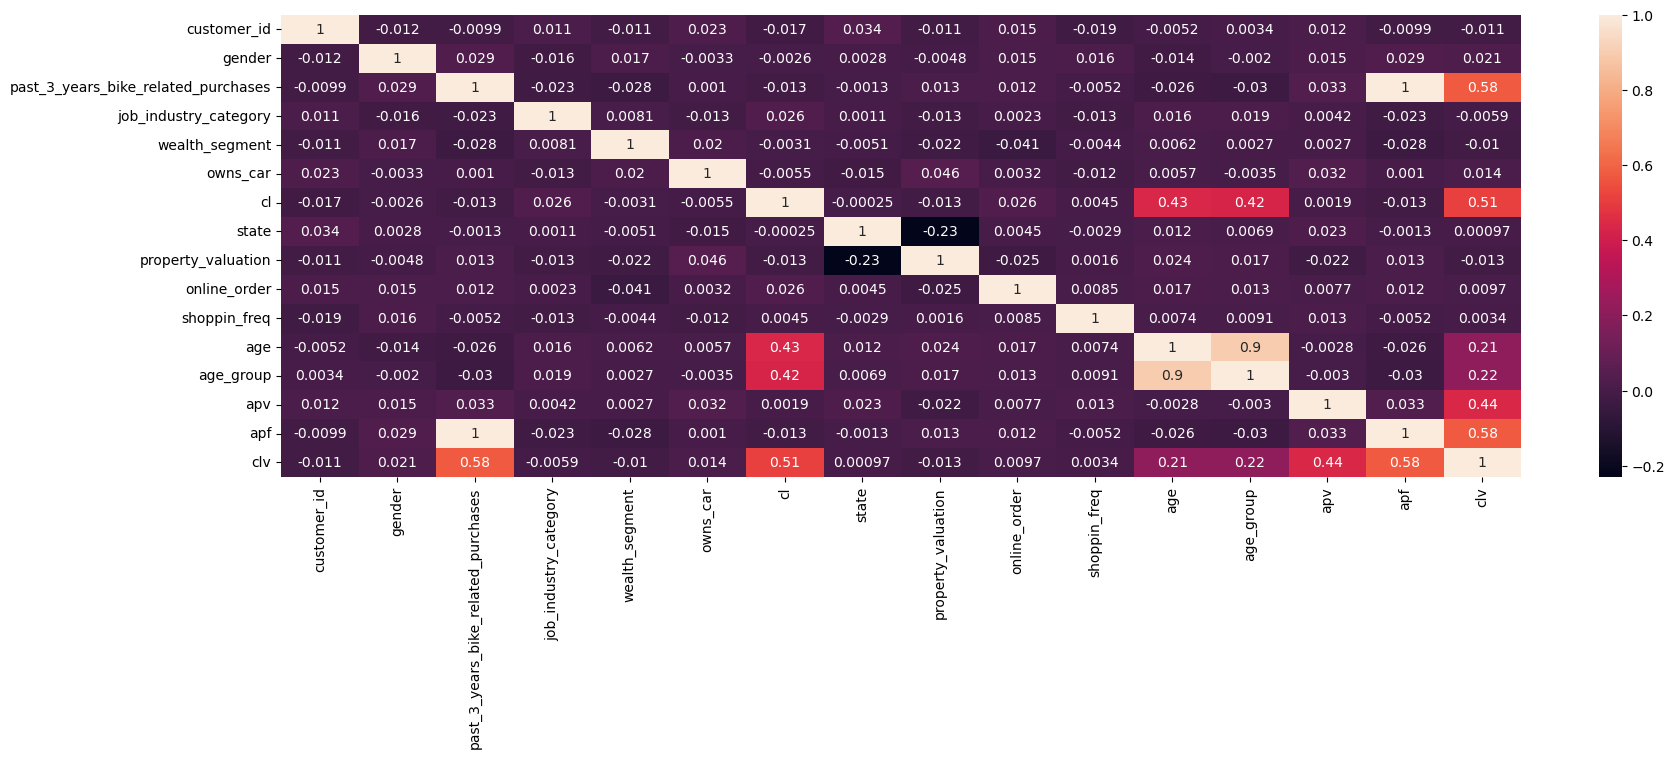

In [32]:
plt.figure(figsize=(20, 6))
core_mat=mer_df.corr()
sb.heatmap(core_mat,annot=True)

1.hypothesis for age_group and clv
2.hypothesis for job_industry_category and clv
3.hypothesis for state and clv
4.hypothesis for wealth_segment and clv
5.hypothesis for own_cars and clv

In [33]:
mer_df.dtypes

customer_id                              int64
gender                                   int64
past_3_years_bike_related_purchases    float64
job_industry_category                    int64
wealth_segment                           int64
deceased_indicator                      object
owns_car                                 int64
cl                                     float64
state                                    int64
property_valuation                     float64
online_order                           float64
shoppin_freq                             int64
age                                    float64
age_group                                int64
apv                                    float64
apf                                    float64
clv                                    float64
dtype: object

In [34]:
mer_df.drop(columns=['deceased_indicator','age','past_3_years_bike_related_purchases','customer_id'],inplace=True)

In [35]:
X = mer_df.drop(columns=['clv'])  # Features
y = mer_df['clv'] 

In [36]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaled_data = scaler.fit_transform(X)

In [37]:
pca = PCA(n_components=5)
pca_result = pca.fit_transform(scaled_data)

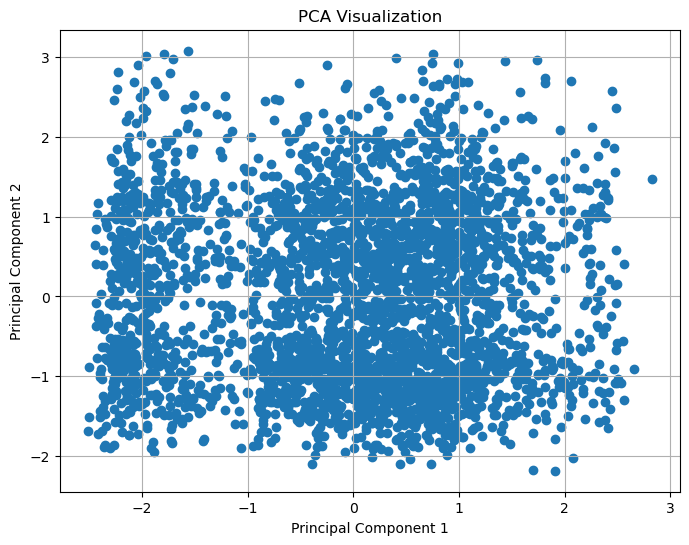

Explained Variance Ratio (first 5 components): [0.11926358 0.10364547 0.08980213 0.08716557 0.0849829 ]


In [38]:
plt.figure(figsize=(8, 6))
plt.scatter(pca_result[:, 0], pca_result[:, 1])
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA Visualization')
plt.grid(True)
plt.show()

print("Explained Variance Ratio (first 5 components):", pca.explained_variance_ratio_)

In [39]:
print("Singular Values (Eigenvalues):", pca.singular_values_)


cumulative_explained_variance = np.cumsum(pca.explained_variance_ratio_)
print("Cumulative Explained Variance:", cumulative_explained_variance)


summary_df = pd.DataFrame({
    'Principal Component': range(1, len(pca.explained_variance_ratio_) + 1),
    'Explained Variance Ratio': pca.explained_variance_ratio_,
    'Cumulative Explained Variance': cumulative_explained_variance
})
print(summary_df)

Singular Values (Eigenvalues): [68.0322066  63.42139599 59.0342373  58.16116708 57.42836036]
Cumulative Explained Variance: [0.11926358 0.22290905 0.31271119 0.39987676 0.48485966]
   Principal Component  Explained Variance Ratio  \
0                    1                  0.119264   
1                    2                  0.103645   
2                    3                  0.089802   
3                    4                  0.087166   
4                    5                  0.084983   

   Cumulative Explained Variance  
0                       0.119264  
1                       0.222909  
2                       0.312711  
3                       0.399877  
4                       0.484860  


In [40]:
pca_df = pd.DataFrame(pca.components_, columns=X.columns, index=['Dim1', 'Dim2', 'Dim3', 'Dim4', 'Dim5'])

print(pca_df)

        gender  job_industry_category  wealth_segment  owns_car        cl  \
Dim1 -0.012314               0.079174       -0.001257 -0.019783  0.701215   
Dim2  0.031940               0.047607        0.028771 -0.159971 -0.011813   
Dim3 -0.371795               0.281163        0.337882 -0.120527 -0.044624   
Dim4  0.239903              -0.058932        0.611617  0.513951  0.022112   
Dim5 -0.472567               0.310521       -0.257114  0.416622  0.001225   

         state  property_valuation  online_order  shoppin_freq  age_group  \
Dim1  0.019162           -0.013108      0.061611      0.021543   0.700845   
Dim2  0.679962           -0.698523      0.078062      0.001499  -0.037508   
Dim3 -0.001199           -0.043802     -0.393419     -0.195574  -0.017847   
Dim4  0.042763           -0.015083     -0.326385     -0.033365   0.036515   
Dim5  0.052537            0.006253      0.196931     -0.561630  -0.022658   

           apv       apf  
Dim1 -0.005112 -0.074001  
Dim2  0.109108 -0.02

In [41]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor 
X_train, X_test, y_train, y_test = train_test_split(pca_result, y, test_size=0.2, random_state=42)

Rf_model = RandomForestRegressor()  # Example: Random Forest Regressor
Rf_model.fit(X_train, y_train)

RandomForestRegressor()

In [42]:
y_predict=Rf_model.predict(X_test)

In [43]:
from sklearn.metrics import mean_absolute_error, r2_score
mean_absolute_error(y_test,y_predict)

144279.57192719524

In [44]:
r2_score(y_test,y_predict)

0.5129740205488128